<a href="https://colab.research.google.com/github/ysuter/FHNW-BSUD-Part2/blob/main/L8-SentimentAnalysis/L08_sentimental_analysis_on_restaurent_reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis on Restaurant Reviews

### 1. Importing Libraries

In [1]:
# Importing necessary libraries for Data Analysis and Visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 2. Reading Data

In [2]:
# df = pd.read_csv('/kaggle/input/restaurant-reviews/Restaurant_Reviews.tsv', sep='\t')
df = pd.read_csv('Restaurant_Reviews.tsv', sep='\t')

In [3]:
# Print the first 5 rows of the 'messages' DataFrame
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  1000 non-null   object
 1   Liked   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


In [5]:
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


### 3. Basic EDA

In [6]:
# Generate summary statistics for the 'messages'
df.describe()

,Liked
count,1000.00000
mean,0.50000
std,0.50025
min,0.00000
25%,0.00000
50%,0.50000
75%,1.00000
max,1.00000


In [7]:
# Print information about the 'messages'
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  1000 non-null   object
 1   Liked   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


In [8]:
# Describing the reviews after grouping
df.groupby('Liked').describe()

Review                                
       count unique                 top freq
Liked                                       
0        500    497    I won't be back.    2
1        500    499  I love this place.    2

In [9]:
# Check for the lengths of the Review texts
df['Length'] = df['Review'].apply(len)
df.head()

,Review,Liked,Length
0,Wow... Loved this place.,1,24
1,Crust is not good.,0,18
2,Not tasty and the texture was just nasty.,0,41
3,Stopped by during the late May bank holiday of...,1,87
4,The selection on the menu was great and so wer...,1,59


In [10]:
# Generate summary statistics for the 'Length' column of the 'messages' DataFrame
df.Length.describe()

,Length
count,1000.000000
mean,58.324000
std,32.349614
min,11.000000
25%,33.000000
50%,51.000000
75%,80.000000
max,149.000000


In [11]:
# Printing the longest review
df_149 =df[df['Length'] == 149]['Review']


for message in df_149:
    print(message)


The problem I have is that they charge $11.99 for a sandwich that is no bigger than a Subway sub (which offers better and more amount of vegetables).


### 4. Data Visualizations

#### Creating a wordcloud with reviews


In [12]:
!pip install wordcloud

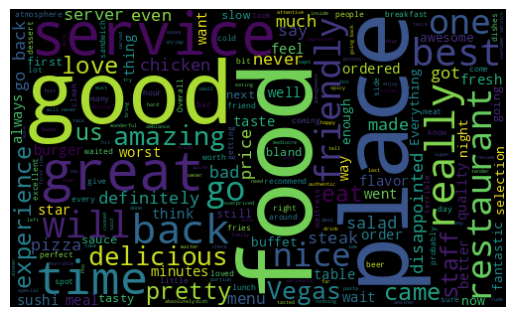

In [13]:
from wordcloud import WordCloud

# Combine all messages into a single string
all_messages = ' '.join(df['Review'])

# Create a WordCloud object with the desired settings
wordCloud = WordCloud(width=500, height=300, random_state=20, max_font_size=100).generate(all_messages)

# Display the WordCloud image
plt.imshow(wordCloud, interpolation='bilinear')
plt.axis('off')
plt.show()

#### Countplot

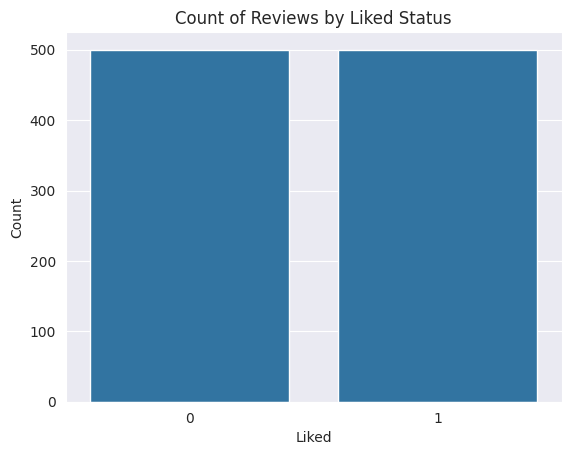

In [14]:
# Set the style of the plot
sns.set_style('darkgrid')

# Create a count plot of the "Liked" column
sns.countplot(x='Liked', data=df)

# Set the title of the plot
plt.title('Count of Reviews by Liked Status')

# Set the label for the x-axis
plt.xlabel('Liked')

# Set the label for the y-axis
plt.ylabel('Count')

# Show the plot
plt.show()


#### Histogram

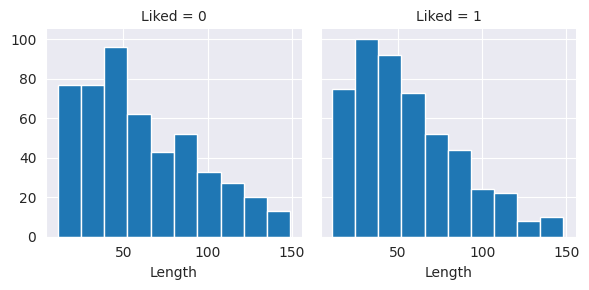

In [15]:
# Create a FacetGrid object with 'Liked' as the column to be used for separating the data
# FacetGrid is a grid of subplots that displays the same relationship between different subsets of your data.
g = sns.FacetGrid(df, col='Liked')

# Use the FacetGrid object to plot a histogram of the 'Length' column for each value of 'Liked'
g.map(plt.hist, 'Length');

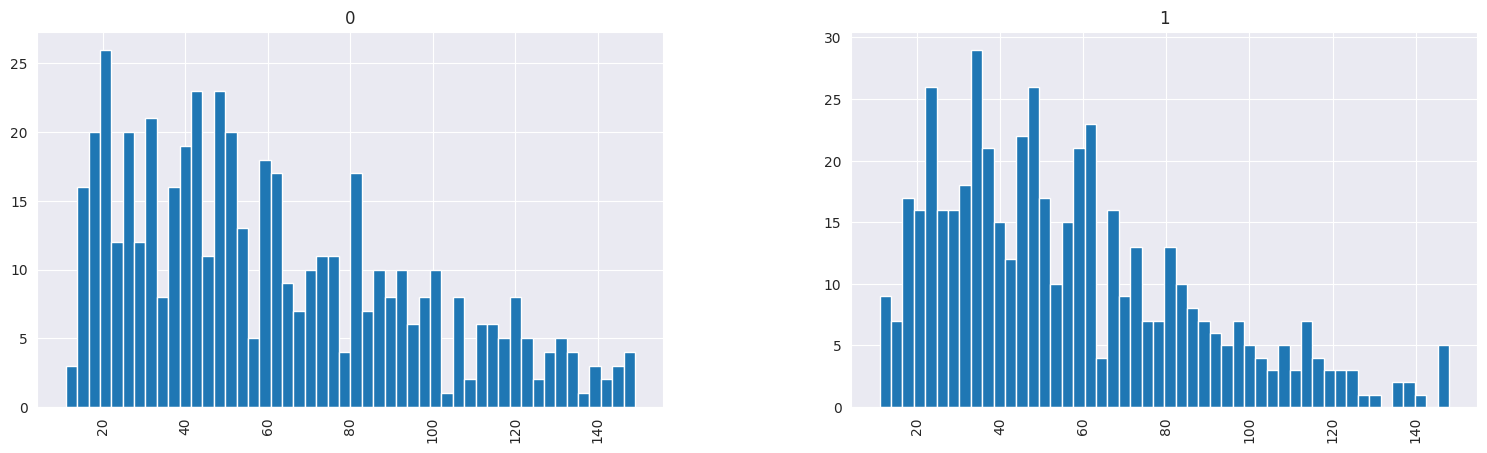

In [16]:
# Comparing length of messages according to category
df.hist(column='Length', by='Liked', bins=50,figsize=(18,5));

In [17]:
# Exclude non-numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Compute the correlation matrix
correlation_matrix = numeric_df.corr()

In [18]:
df.shape

(1000, 3)

In [19]:
# Check for correlation
correlation_matrix.corr()

,Liked,Length
Liked,1.0,-1.0
Length,-1.0,1.0


In [20]:
df.head()

,Review,Liked,Length
0,Wow... Loved this place.,1,24
1,Crust is not good.,0,18
2,Not tasty and the texture was just nasty.,0,41
3,Stopped by during the late May bank holiday of...,1,87
4,The selection on the menu was great and so wer...,1,59


In [21]:
dfnumeric = df[['Liked', 'Length']]

In [22]:
dfnumeric.shape

(1000, 2)

#### Correlation - Heatmap

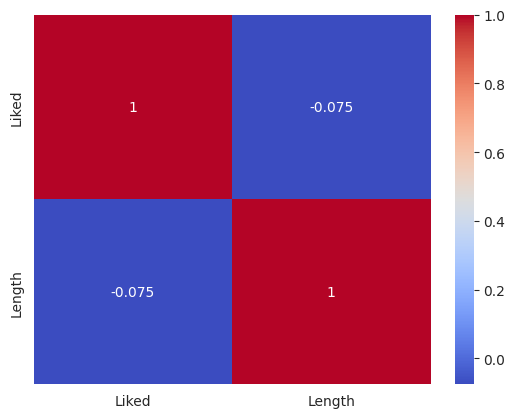

In [23]:
# Display a heatmap with correlation values
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm');

### 5. Data Preprocessing

In [24]:
# Import the CountVectorizer class from the sklearn.feature_extraction.text module
from sklearn.feature_extraction.text import CountVectorizer

In [25]:
# Create a CountVectorizer object with default parameters
cv = CountVectorizer()

In [26]:
# Convert the text data into lowercase and split into features and target variable

X =df['Review'].str.lower()
y = df['Liked']

In [27]:
# Use the CouantVectorizer object to fit and transform the input data (X)
X = cv.fit_transform(X)

### 6. Building Classification Models

In [28]:
# Import the train_test_split function from sklearn.model_selection module
from sklearn.model_selection import train_test_split
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=101)

#### Naives Bayes Classifier

In [29]:
# Import the MultinomialNB class from the sklearn.naive_bayes moduleand create an object of it
from sklearn.naive_bayes import MultinomialNB
# Create a MultinomialNB object
nb = MultinomialNB()

In [30]:
# Train the Naive Bayes model using the training data
nb.fit(X_train,y_train)

MultinomialNB()

In [31]:
# Make predictions on the testing set
predictions = nb.predict(X_test)

In [32]:
# Import confusion_matrix and classification_report from the sklearn.metrics module
from sklearn.metrics import confusion_matrix,classification_report

In [33]:
# Print the confusion matrix
print(confusion_matrix(y_test,predictions))

[[114  36]
 [ 30 120]]


In [34]:
# Classification report for the model
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.79      0.76      0.78       150
           1       0.77      0.80      0.78       150

    accuracy                           0.78       300
   macro avg       0.78      0.78      0.78       300
weighted avg       0.78      0.78      0.78       300



In [35]:
# Import the TfidfTransformer class from the sklearn.feature_extraction.text module
from sklearn.feature_extraction.text import TfidfTransformer

In [36]:
# Import the Pipeline class from the sklearn.pipeline module
from sklearn.pipeline import Pipeline

In [37]:
# Create a pipeline with CountVectorizer, TfidfTransformer, and MultinomialNB objects

pipeline = Pipeline([
    ('bow', CountVectorizer()),  # strings to token integer counts
    ('tfidf', TfidfTransformer()),  # integer counts to weighted TF-IDF scores
    ('classifier', MultinomialNB()),])  # train on TF-IDF vectors, Naive Bayes classifier


In [38]:
# Get the input data and split it into training and testing sets
X = df['Review']
y = df['Liked']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=101)

In [39]:
# Fit the pipeline on the training data

pipeline.fit(X_train,y_train)

Pipeline(steps=[('bow', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('classifier', MultinomialNB())])

In [40]:
# Make predictions on the testing set

predictions = pipeline.predict(X_test)

In [41]:
# Print the confusion matrix and classification report

print(confusion_matrix(y_test,predictions))
print(classification_report(y_test,predictions))

[[111  39]
 [ 23 127]]
              precision    recall  f1-score   support

           0       0.83      0.74      0.78       150
           1       0.77      0.85      0.80       150

    accuracy                           0.79       300
   macro avg       0.80      0.79      0.79       300
weighted avg       0.80      0.79      0.79       300



In [42]:
#logistic regression

from sklearn import linear_model

In [43]:
# Create a logistic regression object

logr=linear_model.LogisticRegression()

In [44]:
X = cv.fit_transform(X)

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=101)

In [46]:
# Fit the model with training dataset

logr.fit(X_train,y_train)

LogisticRegression()

In [47]:
# Use the trained logistic regression model to make predictions on the test set
logpredictions = logr.predict(X_test)

In [48]:
# Print the confusion matrix

print(confusion_matrix(y_test,logpredictions))

[[119  31]
 [ 22 128]]


In [49]:
# Classification Report
print(classification_report(y_test,logpredictions))

              precision    recall  f1-score   support

           0       0.84      0.79      0.82       150
           1       0.81      0.85      0.83       150

    accuracy                           0.82       300
   macro avg       0.82      0.82      0.82       300
weighted avg       0.82      0.82      0.82       300



<hr>

#  Useful Code Snippets

### Wordclouds for visualization

In [50]:
pip install wordcloud


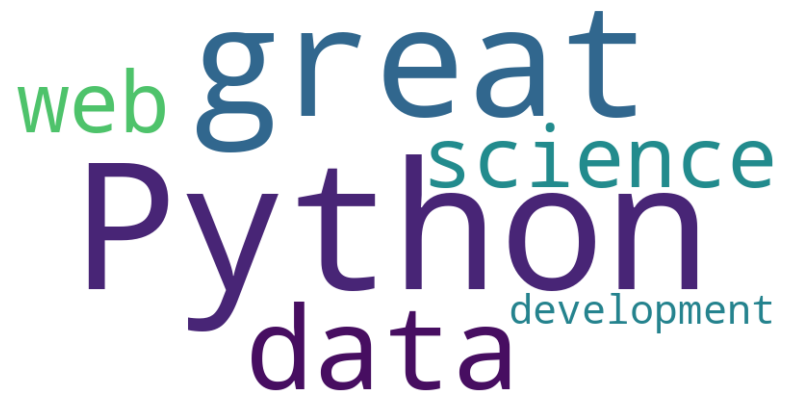

In [51]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Sample text
text = "Python is great for data science. Python is also great for web development."

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


***

### Seaborn and Matplotlib for data analysis and visualizations

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load an example dataset
data = sns.load_dataset('tips')

### Textual and tabular insights into the data

In [53]:
data.shape

(244, 7)

In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [55]:
data.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [56]:
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [57]:
data.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


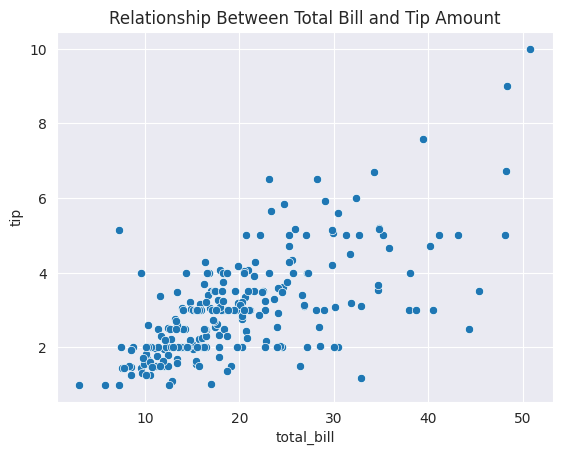

In [58]:


# Create a simple scatter plot
sns.scatterplot(x='total_bill', y='tip', data=data)

# Show the plot
plt.title('Relationship Between Total Bill and Tip Amount')
plt.show()


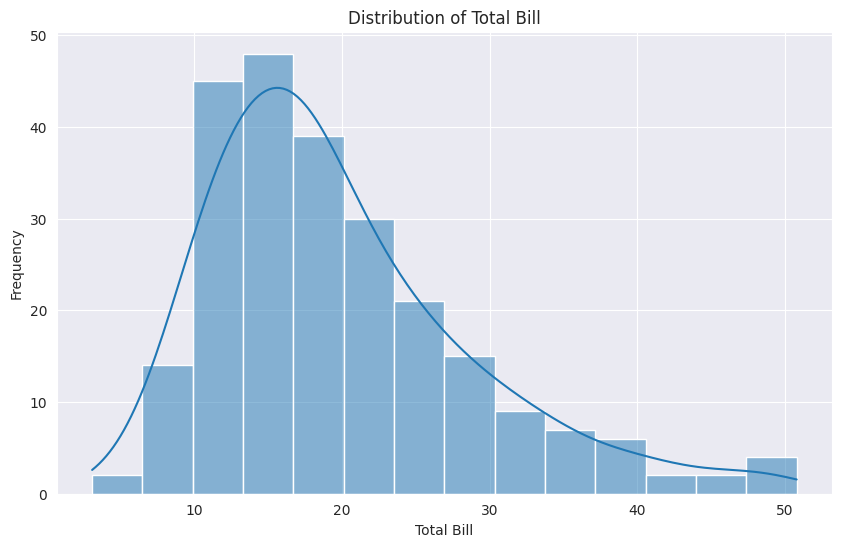

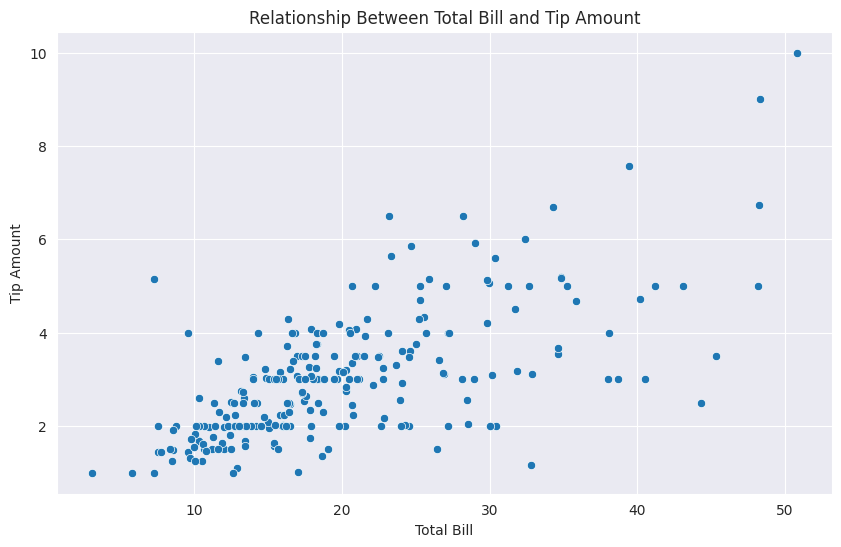

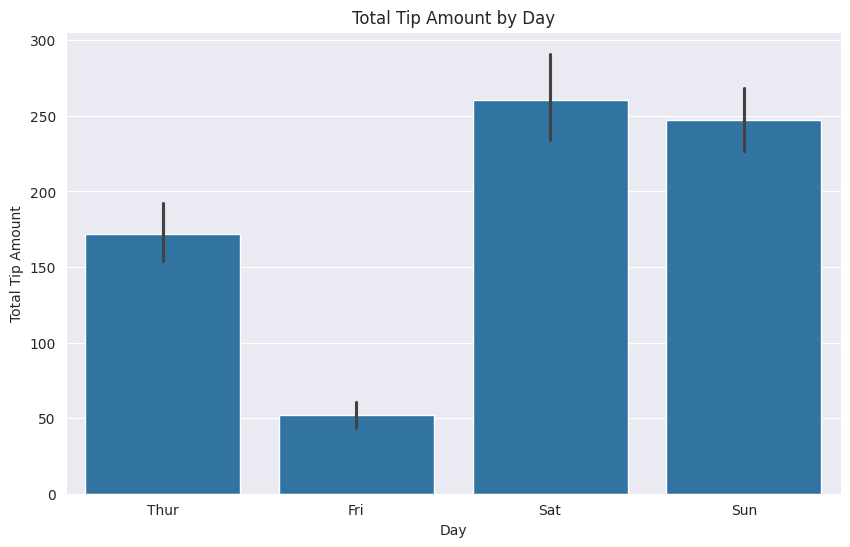

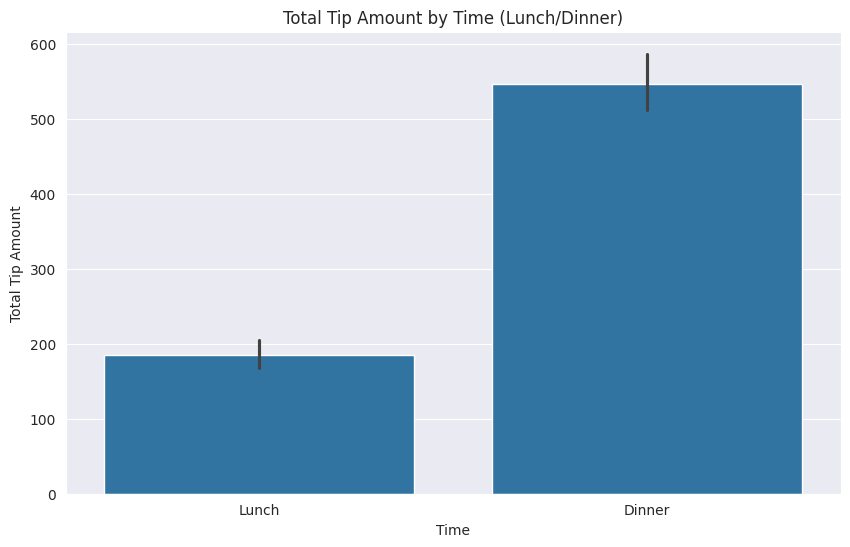

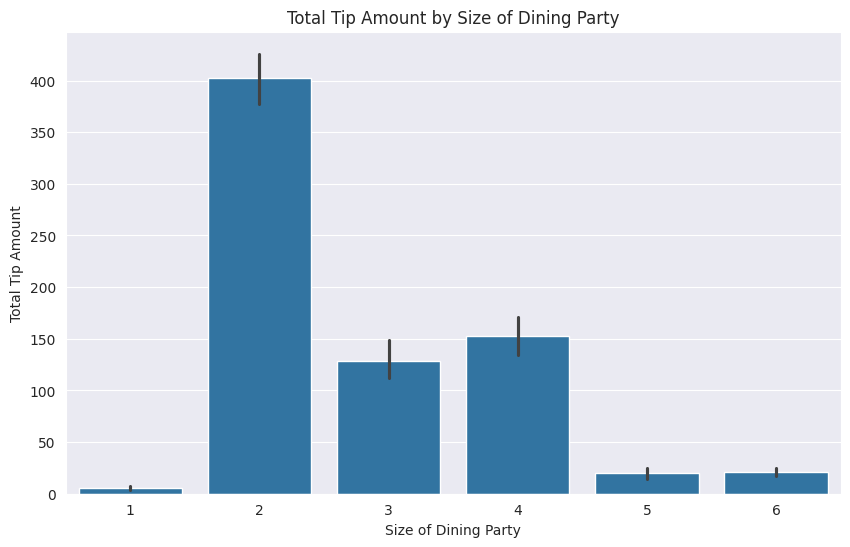

In [59]:
# Visualize the distribution of total_bill
plt.figure(figsize=(10, 6))
sns.histplot(data['total_bill'], kde=True)
plt.title('Distribution of Total Bill')
plt.xlabel('Total Bill')
plt.ylabel('Frequency')
plt.show()

# Visualize the relationship between total_bill and tip
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_bill', y='tip', data=data)
plt.title('Relationship Between Total Bill and Tip Amount')
plt.xlabel('Total Bill')
plt.ylabel('Tip Amount')
plt.show()

# Visualize the total tip amount by day
plt.figure(figsize=(10, 6))
sns.barplot(x='day', y='tip', data=data, estimator=sum)
plt.title('Total Tip Amount by Day')
plt.xlabel('Day')
plt.ylabel('Total Tip Amount')
plt.show()

# Visualize the total tip amount by time (Lunch/Dinner)
plt.figure(figsize=(10, 6))
sns.barplot(x='time', y='tip', data=data, estimator=sum)
plt.title('Total Tip Amount by Time (Lunch/Dinner)')
plt.xlabel('Time')
plt.ylabel('Total Tip Amount')
plt.show()

# Visualize the total tip amount by size of the dining party
plt.figure(figsize=(10, 6))
sns.barplot(x='size', y='tip', data=data, estimator=sum)
plt.title('Total Tip Amount by Size of Dining Party')
plt.xlabel('Size of Dining Party')
plt.ylabel('Total Tip Amount')
plt.show()